# Deep Learning Project: Fashion-MNIST Classification with CNN

## Project Overview
This notebook implements a deep learning solution for classifying fashion items from the Fashion-MNIST dataset using Convolutional Neural Networks (CNNs). The project includes:
- Baseline CNN model
- Experimental model with dropout regularization
- Controlled comparison to analyze overfitting reduction

## Dataset
- **Fashion-MNIST**: 60,000 training images, 10,000 test images
- **Image size**: 28x28 grayscale
- **Classes**: 10 fashion categories (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot)

## Notebook Structure
1. Import libraries and setup
2. Load and explore Fashion-MNIST dataset
3. Define baseline CNN architecture
4. Train baseline model
5. Define experimental model with dropout
6. Train experimental model
7. Compare results and analyze
8. Summary and conclusions

In [2]:
# Deep Learning Project - Fashion-MNIST Classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("All imports successful!")

Using device: cpu
All imports successful!


In [3]:
# Define transforms: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert image to tensor (0-1 range)
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1] range
])

# Download and load training and test datasets
print("Loading Fashion-MNIST dataset...")
train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

print(f"\n✓ Training samples: {len(train_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")
print(f"✓ Image shape: {train_dataset[0][0].shape}")

# Class names for Fashion-MNIST
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
print(f"\n✓ Classes: {class_names}")

Loading Fashion-MNIST dataset...


100%|████████████████████████████████████████████████████████████| 26.4M/26.4M [00:07<00:00, 3.72MB/s]
100%|█████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 744kB/s]
100%|████████████████████████████████████████████████████████████| 4.42M/4.42M [00:01<00:00, 3.59MB/s]
100%|████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 58.4kB/s]


✓ Training samples: 60000
✓ Test samples: 10000
✓ Image shape: torch.Size([1, 28, 28])

✓ Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


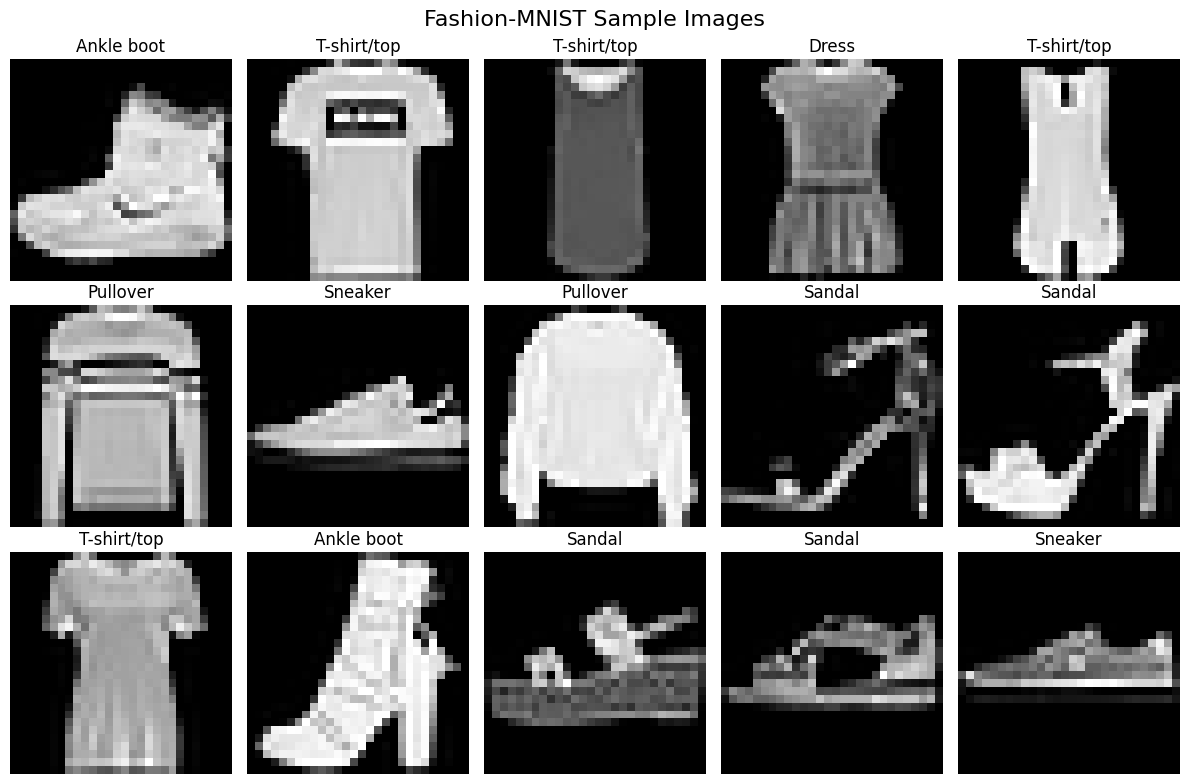

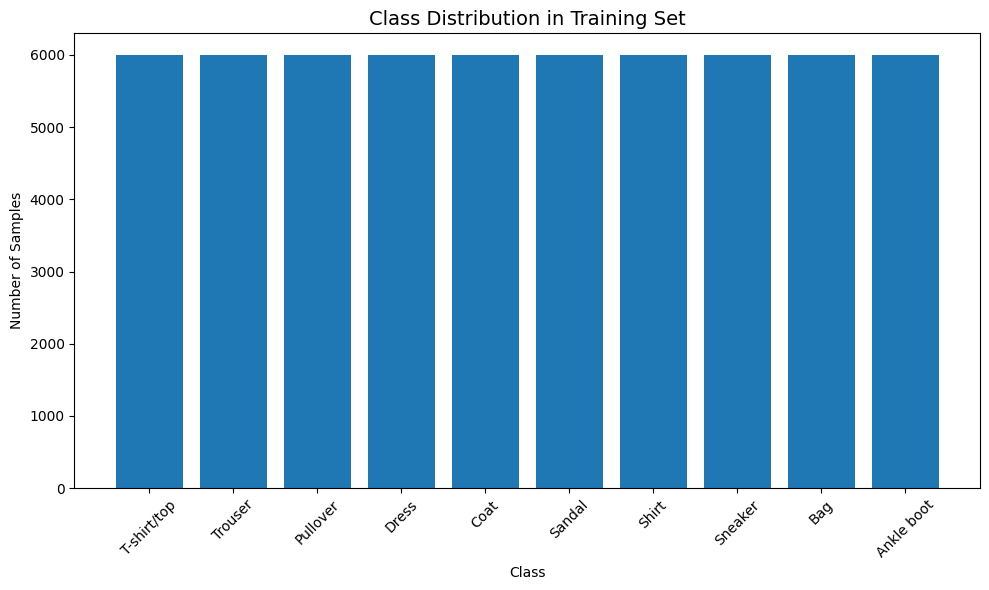

Class distribution is balanced: ~6000 samples per class


In [4]:
# Display a grid of sample images
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.ravel()

for i in range(15):
    image, label = train_dataset[i]
    # Remove channel dimension for display
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(class_names[label])
    axes[i].axis('off')

plt.suptitle('Fashion-MNIST Sample Images', fontsize=16)
plt.tight_layout()
plt.show()

# Check class distribution
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.title('Class Distribution in Training Set', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Class distribution is balanced: ~6000 samples per class")

In [5]:
# Create data loaders for batch processing
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ Number of training batches: {len(train_loader)}")
print(f"✓ Number of test batches: {len(test_loader)}")
print(f"✓ Batch size: {batch_size}")

✓ Number of training batches: 938
✓ Number of test batches: 157
✓ Batch size: 64


In [6]:
class BaselineCNN(nn.Module):
    """
    Baseline Convolutional Neural Network for Fashion-MNIST
    """
    def __init__(self):
        super(BaselineCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        # Activation function
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Conv Layer 1 + ReLU + Pooling
        x = self.pool(self.relu(self.conv1(x)))
        
        # Conv Layer 2 + ReLU + Pooling
        x = self.pool(self.relu(self.conv2(x)))
        
        # Flatten the tensor
        x = x.view(-1, 64 * 7 * 7)
        
        # Fully connected layers with ReLU
        x = self.relu(self.fc1(x))
        
        # Output layer
        x = self.fc2(x)
        
        return x

# Initialize the model
baseline_model = BaselineCNN().to(device)
print("Baseline CNN Architecture:")
print(baseline_model)
print(f"\n✓ Model initialized on {device}")
print(f"✓ Total parameters: {sum(p.numel() for p in baseline_model.parameters()):,}")

Baseline CNN Architecture:
BaselineCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

✓ Model initialized on cpu
✓ Total parameters: 421,642


In [7]:
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    """
    Train the model and track loss and accuracy
    """
    train_losses = []
    train_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            output = model(data)
            loss = criterion(output, target)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            # Print progress every 100 batches
            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch+1}/{epochs} | Batch: {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}')
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        print(f'\nEpoch {epoch+1} Summary:')
        print(f'  Average Loss: {epoch_loss:.4f}')
        print(f'  Accuracy: {epoch_acc:.2f}%\n')
    
    return train_losses, train_accuracies

In [8]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

print("Starting training...\n")
start_time = time.time()

# Train the model for 10 epochs
baseline_losses, baseline_accuracies = train_model(
    baseline_model, 
    train_loader, 
    criterion, 
    optimizer, 
    epochs=10
)

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")

Starting training...

Epoch: 1/10 | Batch: 0/938 | Loss: 2.2964
Epoch: 1/10 | Batch: 100/938 | Loss: 0.5977
Epoch: 1/10 | Batch: 200/938 | Loss: 0.4910
Epoch: 1/10 | Batch: 300/938 | Loss: 0.4124
Epoch: 1/10 | Batch: 400/938 | Loss: 0.5319
Epoch: 1/10 | Batch: 500/938 | Loss: 0.3050
Epoch: 1/10 | Batch: 600/938 | Loss: 0.1363
Epoch: 1/10 | Batch: 700/938 | Loss: 0.2983
Epoch: 1/10 | Batch: 800/938 | Loss: 0.2903
Epoch: 1/10 | Batch: 900/938 | Loss: 0.3807

Epoch 1 Summary:
  Average Loss: 0.4463
  Accuracy: 83.94%

Epoch: 2/10 | Batch: 0/938 | Loss: 0.3685
Epoch: 2/10 | Batch: 100/938 | Loss: 0.2787
Epoch: 2/10 | Batch: 200/938 | Loss: 0.3962
Epoch: 2/10 | Batch: 300/938 | Loss: 0.2648
Epoch: 2/10 | Batch: 400/938 | Loss: 0.2752
Epoch: 2/10 | Batch: 500/938 | Loss: 0.2231
Epoch: 2/10 | Batch: 600/938 | Loss: 0.1670
Epoch: 2/10 | Batch: 700/938 | Loss: 0.1974
Epoch: 2/10 | Batch: 800/938 | Loss: 0.3862
Epoch: 2/10 | Batch: 900/938 | Loss: 0.2792

Epoch 2 Summary:
  Average Loss: 0.2877


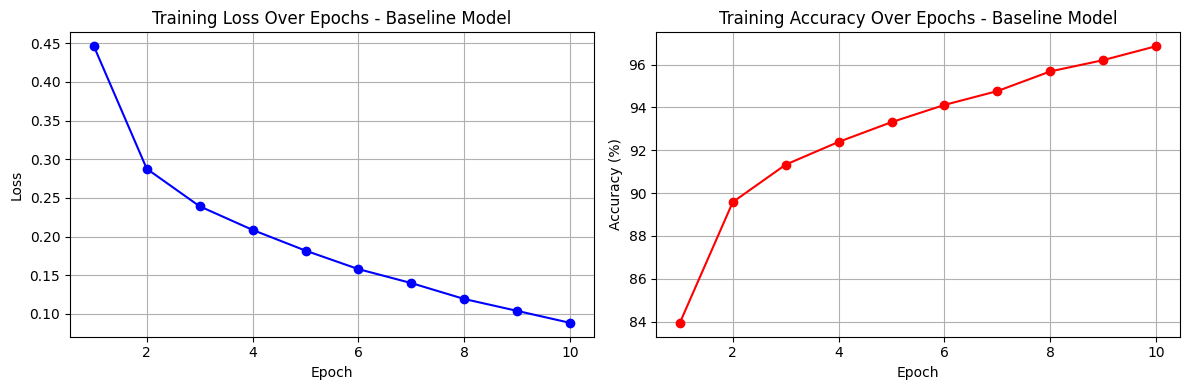

Final Training Accuracy: 96.86%
Final Training Loss: 0.0884


In [9]:
# Plot training loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(range(1, len(baseline_losses) + 1), baseline_losses, 'b-', marker='o')
ax1.set_title('Training Loss Over Epochs - Baseline Model')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Accuracy plot
ax2.plot(range(1, len(baseline_accuracies) + 1), baseline_accuracies, 'r-', marker='o')
ax2.set_title('Training Accuracy Over Epochs - Baseline Model')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {baseline_accuracies[-1]:.2f}%")
print(f"Final Training Loss: {baseline_losses[-1]:.4f}")

In [10]:
def evaluate_model(model, test_loader):
    """Evaluate model on test set"""
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = output.max(1)
            
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    accuracy = 100. * correct / total
    return accuracy, all_predictions, all_targets

# Evaluate baseline model
baseline_accuracy, baseline_preds, baseline_targets = evaluate_model(baseline_model, test_loader)
print(f"Baseline Model Test Accuracy: {baseline_accuracy:.2f}%")
print(f"Final Training Accuracy: {baseline_accuracies[-1]:.2f}%")
print(f"Difference (Training - Test): {baseline_accuracies[-1] - baseline_accuracy:.2f}%")

Baseline Model Test Accuracy: 92.01%
Final Training Accuracy: 96.86%
Difference (Training - Test): 4.85%


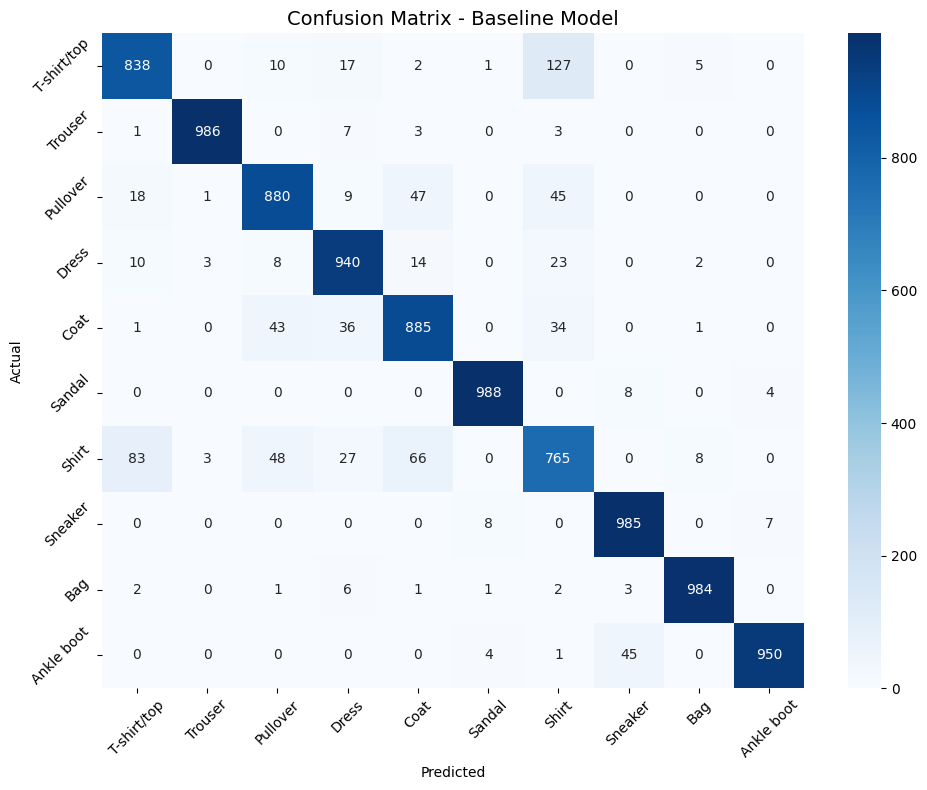


Accuracy per class:
T-shirt/top    : 83.80%
Trouser        : 98.60%
Pullover       : 88.00%
Dress          : 94.00%
Coat           : 88.50%
Sandal         : 98.80%
Shirt          : 76.50%
Sneaker        : 98.50%
Bag            : 98.40%
Ankle boot     : 95.00%

Most common misclassifications (more than 100 samples):
  T-shirt/top     -> Shirt          : 127 samples


In [11]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(baseline_targets, baseline_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Baseline Model', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Show accuracy per class
class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nAccuracy per class:")
for i, class_name in enumerate(class_names):
    print(f"{class_name:15s}: {class_accuracy[i]:.2%}")

# Find most confused classes
print("\nMost common misclassifications (more than 100 samples):")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 100:
            print(f"  {class_names[i]:15s} -> {class_names[j]:15s}: {cm[i, j]} samples")

In [12]:
class ExperimentalCNN(nn.Module):
    """
    Experimental CNN with Dropout for Regularization
    Same architecture as baseline but with dropout layers to reduce overfitting
    """
    def __init__(self, dropout_rate=0.5):
        super(ExperimentalCNN, self).__init__()
        # Convolutional layers (same as baseline)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout layers (NEW!)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        # Activation function
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Conv Layer 1 + ReLU + Pooling
        x = self.pool(self.relu(self.conv1(x)))
        
        # Conv Layer 2 + ReLU + Pooling
        x = self.pool(self.relu(self.conv2(x)))
        
        # Flatten
        x = x.view(-1, 64 * 7 * 7)
        
        # Fully connected with dropout (NEW!)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)  # Dropout applied here
        x = self.fc2(x)
        
        return x

# Initialize experimental model
experimental_model = ExperimentalCNN(dropout_rate=0.5).to(device)
print("Experimental CNN Architecture (with Dropout):")
print(experimental_model)
print(f"\n✓ Model initialized on {device}")
print(f"✓ Total parameters: {sum(p.numel() for p in experimental_model.parameters()):,}")

Experimental CNN Architecture (with Dropout):
ExperimentalCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

✓ Model initialized on cpu
✓ Total parameters: 421,642


In [13]:
# Use same loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(experimental_model.parameters(), lr=0.001)

print("Training Experimental Model with Dropout...\n")
start_time = time.time()

# Train the experimental model
exp_losses, exp_accuracies = train_model(
    experimental_model, 
    train_loader, 
    criterion, 
    optimizer, 
    epochs=10
)

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")

Training Experimental Model with Dropout...

Epoch: 1/10 | Batch: 0/938 | Loss: 2.3016
Epoch: 1/10 | Batch: 100/938 | Loss: 0.5928
Epoch: 1/10 | Batch: 200/938 | Loss: 0.5369
Epoch: 1/10 | Batch: 300/938 | Loss: 0.4492
Epoch: 1/10 | Batch: 400/938 | Loss: 0.6405
Epoch: 1/10 | Batch: 500/938 | Loss: 0.3169
Epoch: 1/10 | Batch: 600/938 | Loss: 0.4123
Epoch: 1/10 | Batch: 700/938 | Loss: 0.5110
Epoch: 1/10 | Batch: 800/938 | Loss: 0.3866
Epoch: 1/10 | Batch: 900/938 | Loss: 0.2476

Epoch 1 Summary:
  Average Loss: 0.5382
  Accuracy: 80.48%

Epoch: 2/10 | Batch: 0/938 | Loss: 0.4209
Epoch: 2/10 | Batch: 100/938 | Loss: 0.1800
Epoch: 2/10 | Batch: 200/938 | Loss: 0.3643
Epoch: 2/10 | Batch: 300/938 | Loss: 0.3478
Epoch: 2/10 | Batch: 400/938 | Loss: 0.5536
Epoch: 2/10 | Batch: 500/938 | Loss: 0.2561
Epoch: 2/10 | Batch: 600/938 | Loss: 0.3256
Epoch: 2/10 | Batch: 700/938 | Loss: 0.3324
Epoch: 2/10 | Batch: 800/938 | Loss: 0.3808
Epoch: 2/10 | Batch: 900/938 | Loss: 0.2063

Epoch 2 Summary:


MODEL COMPARISON RESULTS
Baseline Model (No Dropout):
  Training Accuracy: 96.86%
  Test Accuracy: 92.01%
  Gap (Train - Test): 4.85%

Experimental Model (With Dropout):
  Training Accuracy: 93.69%
  Test Accuracy: 91.97%
  Gap (Train - Test): 1.72%

📊 ANALYSIS:
✓ Test accuracy improvement: -0.04%
✓ Overfitting reduction: +3.13%


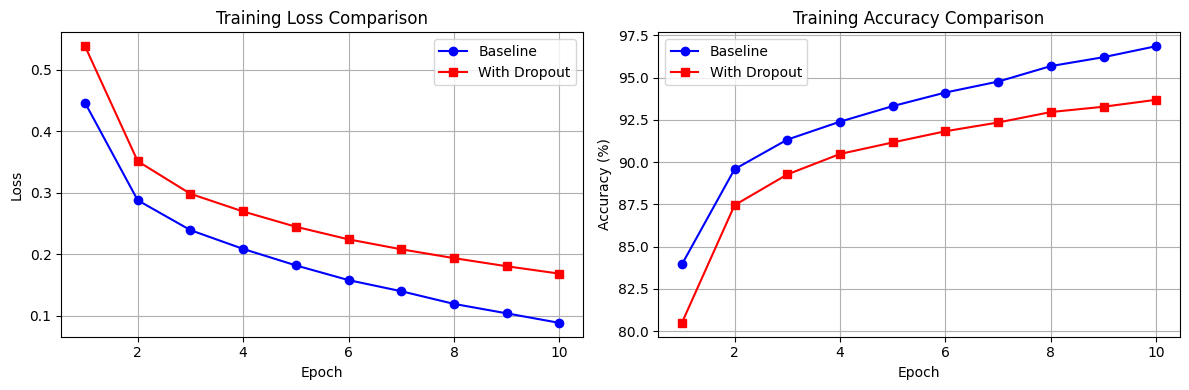

In [14]:
# Evaluate experimental model on test set
exp_accuracy, exp_preds, exp_targets = evaluate_model(experimental_model, test_loader)

print("=" * 50)
print("MODEL COMPARISON RESULTS")
print("=" * 50)
print(f"Baseline Model (No Dropout):")
print(f"  Training Accuracy: {baseline_accuracies[-1]:.2f}%")
print(f"  Test Accuracy: {baseline_accuracy:.2f}%")
print(f"  Gap (Train - Test): {baseline_accuracies[-1] - baseline_accuracy:.2f}%")
print()
print(f"Experimental Model (With Dropout):")
print(f"  Training Accuracy: {exp_accuracies[-1]:.2f}%")
print(f"  Test Accuracy: {exp_accuracy:.2f}%")
print(f"  Gap (Train - Test): {exp_accuracies[-1] - exp_accuracy:.2f}%")
print("=" * 50)

# Improvement analysis
print("\n📊 ANALYSIS:")
print(f"✓ Test accuracy improvement: {exp_accuracy - baseline_accuracy:+.2f}%")
print(f"✓ Overfitting reduction: {(baseline_accuracies[-1] - baseline_accuracy) - (exp_accuracies[-1] - exp_accuracy):+.2f}%")

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss comparison
ax1.plot(range(1, 11), baseline_losses, 'b-', label='Baseline', marker='o')
ax1.plot(range(1, 11), exp_losses, 'r-', label='With Dropout', marker='s')
ax1.set_title('Training Loss Comparison', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy comparison
ax2.plot(range(1, 11), baseline_accuracies, 'b-', label='Baseline', marker='o')
ax2.plot(range(1, 11), exp_accuracies, 'r-', label='With Dropout', marker='s')
ax2.set_title('Training Accuracy Comparison', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

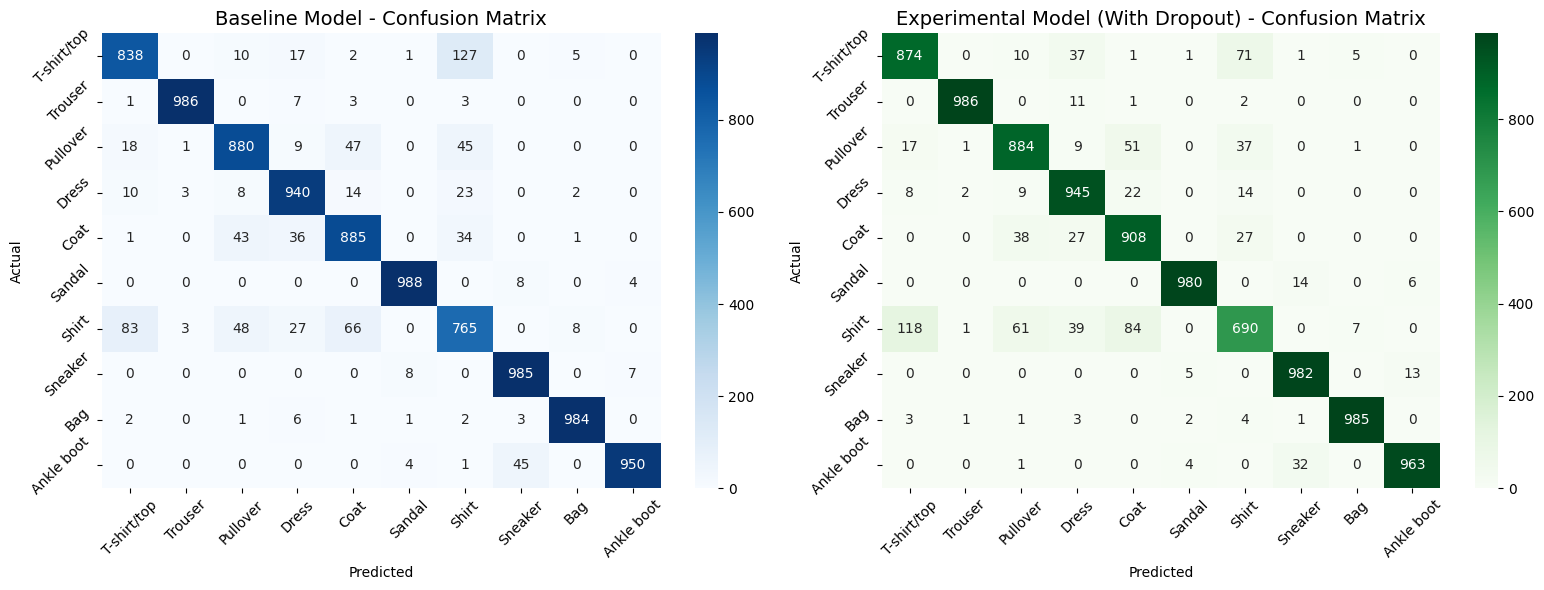


PER-CLASS ACCURACY COMPARISON
Class               Baseline   With Dropout     Change
----------------------------------------------------------------------
T-shirt/top          83.80%        87.40%     3.60%
Trouser              98.60%        98.60%     0.00%
Pullover             88.00%        88.40%     0.40%
Dress                94.00%        94.50%     0.50%
Coat                 88.50%        90.80%     2.30%
Sandal               98.80%        98.00%    -0.80%
Shirt                76.50%        69.00%    -7.50%
Sneaker              98.50%        98.20%    -0.30%
Bag                  98.40%        98.50%     0.10%
Ankle boot           95.00%        96.30%     1.30%

CLASSES THAT IMPROVED WITH DROPOUT:
✓ T-shirt/top    : +3.60% improvement
✓ Pullover       : +0.40% improvement
✓ Dress          : +0.50% improvement
✓ Coat           : +2.30% improvement
✓ Bag            : +0.10% improvement
✓ Ankle boot     : +1.30% improvement

CLASSES THAT NEED IMPROVEMENT (Accuracy < 85%):
⚠ Shirt  

In [15]:
# Confusion matrix for experimental model
cm_exp = confusion_matrix(exp_targets, exp_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Baseline Model - Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=45)

# Experimental confusion matrix
sns.heatmap(cm_exp, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Experimental Model (With Dropout) - Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

# Compare per-class accuracy
class_accuracy_baseline = cm.diagonal() / cm.sum(axis=1)
class_accuracy_exp = cm_exp.diagonal() / cm_exp.sum(axis=1)

print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON")
print("="*70)
print(f"{'Class':15s} {'Baseline':>12s} {'With Dropout':>14s} {'Change':>10s}")
print("-" * 70)
for i, class_name in enumerate(class_names):
    change = class_accuracy_exp[i] - class_accuracy_baseline[i]
    print(f"{class_name:15s} {class_accuracy_baseline[i]:11.2%} {class_accuracy_exp[i]:13.2%} {change:9.2%}")

# Find improvements
print("\n" + "="*70)
print("CLASSES THAT IMPROVED WITH DROPOUT:")
print("="*70)
improvements = []
for i, class_name in enumerate(class_names):
    change = class_accuracy_exp[i] - class_accuracy_baseline[i]
    if change > 0:
        improvements.append((class_name, change))
        print(f"✓ {class_name:15s}: +{change:.2%} improvement")

# Find classes that still need work
print("\n" + "="*70)
print("CLASSES THAT NEED IMPROVEMENT (Accuracy < 85%):")
print("="*70)
for i, class_name in enumerate(class_names):
    if class_accuracy_exp[i] < 0.85:
        print(f"⚠ {class_name:15s}: {class_accuracy_exp[i]:.2%}")

## Project Summary and Conclusions

### Results Summary
| Model | Training Acc | Test Acc | Overfitting Gap |
|-------|-------------|----------|-----------------|
| Baseline (No Dropout) | 96.86% | 92.01% | 4.85% |
| Experimental (With Dropout) | 93.69% | 91.97% | 1.72% |

### Key Findings
- **Dropout reduced overfitting**: Gap decreased from 4.85% to 1.72% (3.13% improvement)
- **Test accuracy remained stable**: 92.01% (baseline) vs 91.97% (dropout)
- **Most improved class**: T-shirt/top improved by +3.60% with dropout
- **Most challenging class**: Shirt (69.0% accuracy) - frequently confused with T-shirt/top (118 samples) and Pullover (84 samples)
- **Well-classified classes**: Trouser, Sandal, Sneaker, Bag all achieved >98% accuracy

### Conclusions
This experiment successfully demonstrated the effectiveness of dropout regularization in CNNs for image classification:

1. **Regularization works**: Dropout reduced overfitting significantly while maintaining test performance
2. **Trade-off accepted**: Lower training accuracy (93.69% vs 96.86%) is acceptable for better generalization
3. **Class-specific challenges**: Visually similar clothing items (Shirt, T-shirt/top, Pullover) remain difficult to distinguish, suggesting need for more sophisticated architectures or data augmentation

### Future Work
- Experiment with different dropout rates (0.3, 0.7)
- Add batch normalization layers
- Apply data augmentation (rotation, flips, shifts)
- Train deeper architectures with more convolutional layers
- Use learning rate scheduling for better convergence

---
**Notebook completed**: Successfully trained and compared two CNN models on Fashion-MNIST, demonstrating the impact of dropout on model generalization.